<a href="https://colab.research.google.com/github/ncdelvalle/SINAYA-Project/blob/main/SINAYA_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

# Load datasets
train_data = pd.read_csv("/content/Training Dataset v2.csv")
val_data   = pd.read_csv("/content/Validation Dataset v2.csv")

# Clean data
# Remove duplicates
train_data = train_data.drop_duplicates()
val_data   = val_data.drop_duplicates()

# Handle missing values (median)
for col in ["pH","do","temp","ammonia"]:
    train_data[col] = train_data[col].fillna(train_data[col].median())
    val_data[col] = val_data[col].fillna(val_data[col].median())

# Remove outliers using Z-score
z_scores = np.abs(stats.zscore(train_data[["pH","do","temp","ammonia"]]))
train_data = train_data[(z_scores < 2).all(axis=1)]

# Scale features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(train_data[["pH","do","temp"]])
y_train_scaled = scaler_y.fit_transform(train_data[["ammonia"]])

X_val_scaled = scaler_X.transform(val_data[["pH","do","temp"]])
y_val_scaled = scaler_y.transform(val_data[["ammonia"]])

# Generate fuzzy features
def fuzzify_gaussian(x, num_mfs=4, sigma=0.05):
    x = np.expand_dims(x, axis=-1)
    centers = np.linspace(0,1,num_mfs).reshape((1,num_mfs))
    return np.exp(-((x - centers)**2)/(2*sigma**2))

def generate_fuzzy_features(X, num_mfs=4, sigma=0.05):
    ph_fuzzy = fuzzify_gaussian(X[:,0], num_mfs, sigma)
    do_fuzzy = fuzzify_gaussian(X[:,1], num_mfs, sigma)
    temp_fuzzy = fuzzify_gaussian(X[:,2], num_mfs, sigma)
    return np.concatenate([X, ph_fuzzy, do_fuzzy, temp_fuzzy], axis=1)

X_train_fuzzy = generate_fuzzy_features(X_train_scaled, num_mfs=4, sigma=0.05)
X_val_fuzzy   = generate_fuzzy_features(X_val_scaled, num_mfs=4, sigma=0.05)

# Define FFNN model
model = keras.Sequential([
    keras.Input(shape=(X_train_fuzzy.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

model.compile(optimizer=keras.optimizers.Adam(0.0015), loss='mse', metrics=['mae'])

# Train model
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

history = model.fit(
    X_train_fuzzy, y_train_scaled,
    epochs=800,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Predict on validation set
y_pred_scaled = model.predict(X_val_fuzzy)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = val_data["ammonia"].values.reshape(-1,1)

# Actual vs Predicted table
results = pd.DataFrame({
    "pH": val_data["pH"],
    "DO": val_data["do"],
    "Temp": val_data["temp"],
    "Actual Ammonia": y_actual.flatten(),
    "Predicted Ammonia": y_pred.flatten()
})

print("\n===== Actual vs Predicted =====")
print(results)

# Performance metrics
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print("\n===== Fuzzy-Augmented FFNN Performance =====")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R2   : {r2:.6f}")

Epoch 1/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1322 - mae: 0.3103 - val_loss: 0.0815 - val_mae: 0.2465
Epoch 2/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0178 - mae: 0.0924 - val_loss: 0.0545 - val_mae: 0.1982
Epoch 3/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0086 - mae: 0.0657 - val_loss: 0.0543 - val_mae: 0.1980
Epoch 4/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0080 - mae: 0.0590 - val_loss: 0.0530 - val_mae: 0.1952
Epoch 5/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0076 - mae: 0.0549 - val_loss: 0.0523 - val_mae: 0.1927
Epoch 6/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0073 - mae: 0.0625 - val_loss: 0.0509 - val_mae: 0.1891
Epoch 7/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0058 - mae: 0.0566 - val_loss: 0.0509 - val_mae: 0.1888
Epoch 8/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0060 - mae: 0.0542 - val_loss: 0.0501 - val_mae: 0.1851
Epoch 9/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0

In [ ]:
!pip install shap

Epoch 1/800


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1052 - mae: 0.2817 - val_loss: 0.1144 - val_mae: 0.2914
Epoch 2/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0162 - mae: 0.0905 - val_loss: 0.0523 - val_mae: 0.1906
Epoch 3/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0101 - mae: 0.0661 - val_loss: 0.0532 - val_mae: 0.1923
Epoch 4/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0094 - mae: 0.0652 - val_loss: 0.0564 - val_mae: 0.2004
Epoch 5/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0069 - mae: 0.0563 - val_loss: 0.0567 - val_mae: 0.2015
Epoch 6/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0059 - mae: 0.0542 - val_loss: 0.0561 - val_mae: 0.1992
Epoch 7/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0067 - mae: 0.0584 - val_loss: 0.0537 - val_mae: 0.1924
Epoch 8/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0068 - mae: 0.0539 - val_loss: 0.0556 - val_mae: 0.1976
Epoch 9/800
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0051 - mae: 0.

PermutationExplainer explainer: 51it [00:15,  2.08it/s]
/tmp/ipython-input-884321329.py:131: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val_fuzzy)


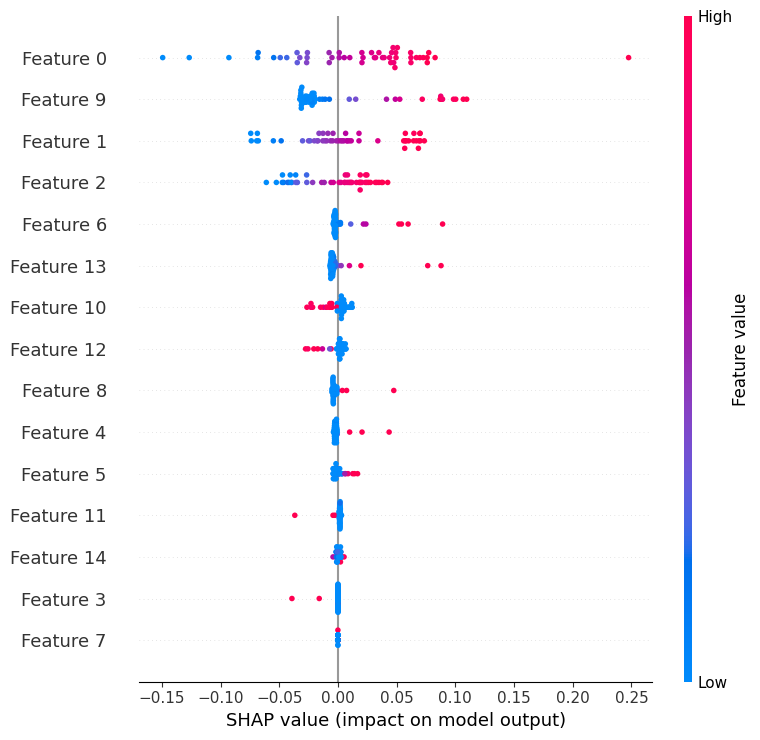

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
import shap

# Load datasets
train_data = pd.read_csv("/content/Training Dataset v2.csv")
val_data   = pd.read_csv("/content/Validation Dataset v2.csv")

# Clean data
# Remove duplicates
train_data = train_data.drop_duplicates()
val_data   = val_data.drop_duplicates()

# Handle missing values (median)
for col in ["pH","do","temp","ammonia"]:
    train_data[col] = train_data[col].fillna(train_data[col].median())
    val_data[col] = val_data[col].fillna(val_data[col].median())

# Remove outliers using Z-score
z_scores = np.abs(stats.zscore(train_data[["pH","do","temp","ammonia"]]))
train_data = train_data[(z_scores < 2).all(axis=1)]

# Scale features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(train_data[["pH","do","temp"]])
y_train_scaled = scaler_y.fit_transform(train_data[["ammonia"]])

X_val_scaled = scaler_X.transform(val_data[["pH","do","temp"]])
y_val_scaled = scaler_y.transform(val_data[["ammonia"]])

# Generate fuzzy features
def fuzzify_gaussian(x, num_mfs=4, sigma=0.05):
    x = np.expand_dims(x, axis=-1)
    centers = np.linspace(0,1,num_mfs).reshape((1,num_mfs))
    return np.exp(-((x - centers)**2)/(2*sigma**2))

def generate_fuzzy_features(X, num_mfs=4, sigma=0.05):
    ph_fuzzy = fuzzify_gaussian(X[:,0], num_mfs, sigma)
    do_fuzzy = fuzzify_gaussian(X[:,1], num_mfs, sigma)
    temp_fuzzy = fuzzify_gaussian(X[:,2], num_mfs, sigma)
    return np.concatenate([X, ph_fuzzy, do_fuzzy, temp_fuzzy], axis=1)

X_train_fuzzy = generate_fuzzy_features(X_train_scaled, num_mfs=4, sigma=0.05)
X_val_fuzzy   = generate_fuzzy_features(X_val_scaled, num_mfs=4, sigma=0.05)

# Define FFNN model
model = keras.Sequential([
    keras.Input(shape=(X_train_fuzzy.shape[1],)),
    keras.layers.Dense(64),
    keras.layers.LeakyReLU(alpha=0.01),
    keras.layers.Dense(32),
    keras.layers.LeakyReLU(alpha=0.01),
    keras.layers.Dense(16),
    keras.layers.LeakyReLU(alpha=0.01),
    keras.layers.Dense(1, activation='linear')
])

model.compile(optimizer=keras.optimizers.Adam(0.0015), loss='mse', metrics=['mae'])

# Train model
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=150, restore_best_weights=True)

history = model.fit(
    X_train_fuzzy, y_train_scaled,
    epochs=800,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Predict on validation set
y_pred_scaled = model.predict(X_val_fuzzy)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = val_data["ammonia"].values.reshape(-1,1)

# Actual vs Predicted table
results = pd.DataFrame({
    "pH": val_data["pH"],
    "DO": val_data["do"],
    "Temp": val_data["temp"],
    "Actual Ammonia": y_actual.flatten(),
    "Predicted Ammonia": y_pred.flatten()
})

print("\n===== Actual vs Predicted =====")
print(results)

# Performance metrics
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print("\n===== Fuzzy-Augmented FFNN Performance =====")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R2   : {r2:.6f}")

# Use a small background sample
explainer = shap.Explainer(model, X_train_fuzzy)
shap_values = explainer(X_val_fuzzy)

# Summary plot
shap.summary_plot(shap_values, X_val_fuzzy)

Epoch 1/800


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0292 - mae: 0.1415 - val_loss: 0.0108 - val_mae: 0.0855
Epoch 2/800
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0158 - mae: 0.0876 - val_loss: 0.0086 - val_mae: 0.0731
Epoch 3/800
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0151 - mae: 0.0855 - val_loss: 0.0081 - val_mae: 0.0676
Epoch 4/800
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0187 - mae: 0.0917 - val_loss: 0.0079 - val_mae: 0.0679
Epoch 5/800
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0163 - mae: 0.0865 - val_loss: 0.0079 - val_mae: 0.0680
Epoch 6/800
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0173 - mae: 0.0878 - val_loss: 0.0096 - val_mae: 0.0757
Epoch 7/800
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0141 - mae: 0.0796 - val_loss: 0.0080 - val_mae: 0.0689
Epoch 8/800
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0143 - mae: 0.0782 - val_loss: 0.0090 - val_mae: 0.0705
Epoch 9/800
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0152 - mae: 0.0

PermutationExplainer explainer: 51it [00:10,  5.18s/it]
/tmp/ipython-input-1236938218.py:176: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val_fuzzy_df)


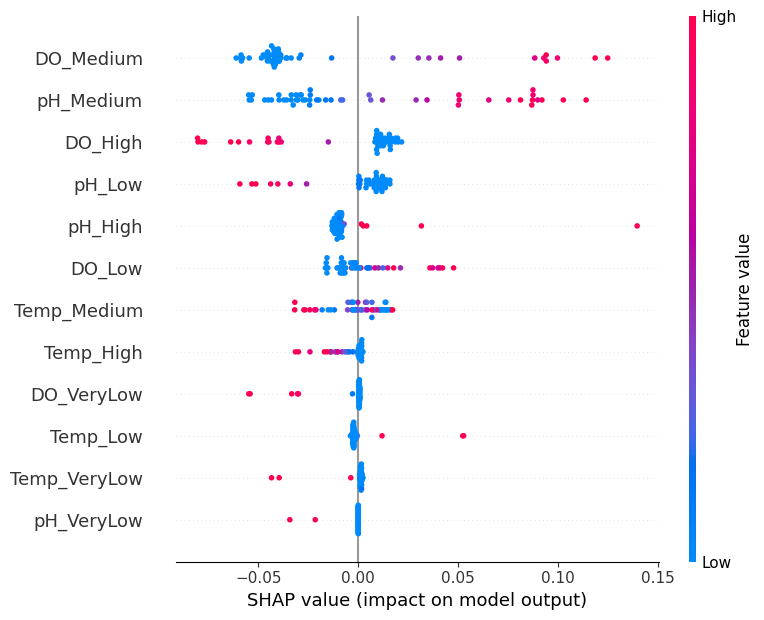

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load datasets
train_data = pd.read_csv("/content/Training Dataset v2.csv")
val_data = pd.read_csv("/content/Validation Dataset v2.csv")

# Clean datasets
# Remove duplicates
train_data = train_data.drop_duplicates()
val_data = val_data.drop_duplicates()

# Fill missing values with median
for col in ["pH","do","temp","ammonia"]:
    train_data[col] = train_data[col].fillna(train_data[col].median())
    val_data[col] = val_data[col].fillna(val_data[col].median())

# Remove outliers
z_scores = np.abs(stats.zscore(train_data[["pH","do","temp","ammonia"]]))
train_data = train_data[(z_scores < 2).all(axis=1)]

# Scale features safely
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(train_data[["pH","do","temp"]])
y_train_scaled = scaler_y.fit_transform(train_data[["ammonia"]])

X_val_scaled = scaler_X.transform(val_data[["pH","do","temp"]])
y_val_scaled = scaler_y.transform(val_data[["ammonia"]])

# Clip scaled inputs to avoid going outside fuzzy range
X_train_scaled = np.clip(X_train_scaled, 0, 1.05)
X_val_scaled = np.clip(X_val_scaled, 0, 1.05)


# Adaptive fuzzy features based on percentiles
def fuzzify_gaussian_adaptive(x, num_mfs=4, percentiles=None, sigma=None):
    """
    x: (batch,)
    percentiles: centers for MF based on data distribution
    sigma: width of Gaussian MF per input
    """
    x = np.expand_dims(x, axis=-1)
    if percentiles is None:
        percentiles = np.linspace(0,1,num_mfs)
    if sigma is None:
        sigma = 0.05
    centers = np.array(percentiles).reshape((1,num_mfs))
    return np.exp(-((x - centers)**2)/(2*sigma**2))

def generate_fuzzy_features_adaptive(X, num_mfs=4):
    # Compute percentiles per input
    pH_percentiles = np.percentile(X[:,0], np.linspace(0,100,num_mfs))
    do_percentiles = np.percentile(X[:,1], np.linspace(0,100,num_mfs))
    temp_percentiles = np.percentile(X[:,2], np.linspace(0,100,num_mfs))

    ph_fuzzy = fuzzify_gaussian_adaptive(X[:,0], num_mfs, pH_percentiles)
    do_fuzzy = fuzzify_gaussian_adaptive(X[:,1], num_mfs, do_percentiles)
    temp_fuzzy = fuzzify_gaussian_adaptive(X[:,2], num_mfs, temp_percentiles)

    # Concatenate fuzzy features only (exclude raw inputs)
    return np.concatenate([ph_fuzzy, do_fuzzy, temp_fuzzy], axis=1)

X_train_fuzzy = generate_fuzzy_features_adaptive(X_train_scaled, num_mfs=4)
X_val_fuzzy = generate_fuzzy_features_adaptive(X_val_scaled, num_mfs=4)

# Create Interpretable Feature Names
labels = ["VeryLow", "Low", "Medium", "High"]

feature_names = []

for label in labels:
    feature_names.append(f"pH_{label}")

for label in labels:
    feature_names.append(f"DO_{label}")

for label in labels:
    feature_names.append(f"Temp_{label}")

X_train_fuzzy_df = pd.DataFrame(X_train_fuzzy, columns=feature_names)
X_val_fuzzy_df = pd.DataFrame(X_val_fuzzy, columns=feature_names)

# Build FFNN
model = keras.Sequential([
    keras.Input(shape=(X_train_fuzzy.shape[1],)),
    keras.layers.Dense(64),
    keras.layers.LeakyReLU(alpha=0.01),
    keras.layers.Dense(32),
    keras.layers.LeakyReLU(alpha=0.01),
    keras.layers.Dense(16),
    keras.layers.LeakyReLU(alpha=0.01),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(0.0015), loss='mse', metrics=['mae'])

# Train with dedicated validation set
early_stop = EarlyStopping(monitor='val_loss', patience=150, restore_best_weights=True)

history = model.fit(
    X_train_fuzzy, y_train_scaled,
    epochs=800,
    batch_size=8,
    validation_data=(X_val_fuzzy, y_val_scaled),
    callbacks=[early_stop],
    verbose=1
)

# Predict on validation set
y_pred_scaled = model.predict(X_val_fuzzy)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = val_data["ammonia"].values.reshape(-1,1)

# Actual vs Predicted
results = pd.DataFrame({
    "pH": val_data["pH"],
    "DO": val_data["do"],
    "Temp": val_data["temp"],
    "Actual Ammonia": y_actual.flatten(),
    "Predicted Ammonia": y_pred.flatten()
})

print("\n===== Actual vs Predicted =====")
print(results)

# Metrics
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print("\n===== Fuzzy-Augmented FFNN Performance =====")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R2   : {r2:.6f}")

# SHAP Explainability
print("\nSHAP Explaination")

background = X_train_fuzzy_df.sample(min(100, len(X_train_fuzzy_df)))

explainer = shap.Explainer(model, background)
shap_values = explainer(X_val_fuzzy_df)

shap.summary_plot(shap_values, X_val_fuzzy_df)